# Bank Marketing Campaign Analysis

## Project Objective
Explore customer and campaign characteristics associated with **term-deposit subscription (`y`)**.

### Notebook Workflow
1. Data Loading & Understanding
2. Data Quality & Cleaning
3. Feature Engineering
4. Exploratory Data Analysis
5. Multivariate Analysis
6. Key Findings & Conclusions

> **Analysis principle:** This notebook focuses on associations in the data. Observed relationships do not imply causation.
________

## 1. Data Loading & Understanding


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


In [41]:
df = pd.read_csv('Dataset\\bank+marketing\\bank\\bank-full.csv' , sep=';')

In [42]:
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [43]:
df.shape

(45211, 17)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [45]:
df.describe(include='all')

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


### Initial Dataset Overview
- **45,211 rows**
- **17 columns**
- Target variable: **`y`**
- 7 numerical features and 10 categorical features
- No pandas-level null values were found in the initial check


_________
## 2. Data Quality & Cleaning

### Missing Values


In [46]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

There are no pandas-level null values. The dataset does contain the categorical value **`unknown`** for unavailable information, so it should not automatically be treated as a numeric missing value.


In [47]:
(df.loc[:, df.dtypes == 'object'] == 'unknown').sum()

job            288
marital          0
education     1857
default          0
housing          0
loan             0
contact      13020
month            0
poutcome     36959
y                0
dtype: int64

### Data Types


In [48]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

### Duplicate Records


In [49]:
df.duplicated().sum()

0

No duplicate rows were found.


### Outlier Screening
IQR-based screening is used to **identify unusual observations**, not automatically delete them. Extreme values can be valid observations in this business dataset.


In [50]:
for i in df.columns:
    if df[i].dtype != 'object':
        print(f"Column: {i}")
        q1 = df[i].quantile(0.25)
        q3 = df[i].quantile(0.75)
        IQR = q3 - q1

        lower_bound = q1 - 1.5 * IQR
        upper_bound = q3 + 1.5 * IQR

        print("Lower Bound:", lower_bound)
        print("Upper Bound:", upper_bound)
        print(f"Total numbers above upper bound in {i}: {(df[i] > upper_bound).sum()}")
        print(f"Total numbers below lower bound in {i}: {(df[i] < lower_bound).sum()}")

Column: age
Lower Bound: 10.5
Upper Bound: 70.5
Total numbers above upper bound in age: 487
Total numbers below lower bound in age: 0
Column: balance
Lower Bound: -1962.0
Upper Bound: 3462.0
Total numbers above upper bound in balance: 4712
Total numbers below lower bound in balance: 17
Column: day
Lower Bound: -11.5
Upper Bound: 40.5
Total numbers above upper bound in day: 0
Total numbers below lower bound in day: 0
Column: duration
Lower Bound: -221.0
Upper Bound: 643.0
Total numbers above upper bound in duration: 3235
Total numbers below lower bound in duration: 0
Column: campaign
Lower Bound: -2.0
Upper Bound: 6.0
Total numbers above upper bound in campaign: 3064
Total numbers below lower bound in campaign: 0
Column: pdays
Lower Bound: -1.0
Upper Bound: -1.0
Total numbers above upper bound in pdays: 8257
Total numbers below lower bound in pdays: 0
Column: previous
Lower Bound: 0.0
Upper Bound: 0.0
Total numbers above upper bound in previous: 8257
Total numbers below lower bound in p

### Special Values: `pdays` and `previous`
`pdays = -1` and `previous = 0` have a meaningful interpretation for customers with no previous campaign contact. They should not be removed simply because an IQR rule flags them.


In [51]:
((df['previous'] == 0) & (df['pdays'] == -1)).sum()

36954

In [52]:
((df['previous'] == 0) & (df['pdays'] != -1)).sum()

0

__________
## 3. Feature Engineering

### Age Groups
The original `age` variable is transformed into three interpretable groups:
- **Young:** 18–30
- **Adult:** 31–60
- **Old:** 61–95


In [53]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 30, 60, 95],
    labels=['Young', 'Adult', 'Old'],
    include_lowest=True
)

In [54]:
df['age_group'].value_counts()

age_group
Adult    36993
Young     7030
Old       1188
Name: count, dtype: int64

### Call Duration Groups
`duration` is measured in **seconds**. It is grouped into practical time intervals to make the relationship with subscription easier to interpret.


In [55]:
df['duration_group'] = pd.cut(
    df['duration'],
    bins=[0, 60, 180, 300, float('inf')],
    labels=['< 1 min', '1–3 min', '3–5 min', '> 5 min'],
    include_lowest=True
)

In [56]:
df['duration_group'].value_counts()

duration_group
1–3 min    17894
> 5 min    12274
3–5 min    10277
< 1 min     4766
Name: count, dtype: int64

_________
## 4. Exploratory Data Analysis

### 4.1 Target Distribution


In [57]:
df['y'].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

The target is imbalanced: approximately **88.3%** of customers did not subscribe, while **11.7%** subscribed. This baseline is important when interpreting later subscription rates.


### 4.2 Categorical Features vs Subscription


#### Job vs Subscription


In [58]:
df['y'].groupby([df['job']]).value_counts(normalize=True)

job            y  
admin.         no     0.877973
               yes    0.122027
blue-collar    no     0.927250
               yes    0.072750
entrepreneur   no     0.917283
               yes    0.082717
housemaid      no     0.912097
               yes    0.087903
management     no     0.862444
               yes    0.137556
retired        no     0.772085
               yes    0.227915
self-employed  no     0.881571
               yes    0.118429
services       no     0.911170
               yes    0.088830
student        no     0.713220
               yes    0.286780
technician     no     0.889430
               yes    0.110570
unemployed     no     0.844973
               yes    0.155027
unknown        no     0.881944
               yes    0.118056
Name: proportion, dtype: float64

**Insight:** Subscription rates vary across job categories. Student and retired customers show notably higher subscription rates than several other groups.


#### Age Group vs Subscription


In [59]:
df['y'].groupby([df['age_group']]).value_counts(normalize=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_4172\2296385356.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['y'].groupby([df['age_group']]).value_counts(normalize=True)


age_group  y  
Young      no     0.837127
           yes    0.162873
Adult      no     0.901549
           yes    0.098451
Old        no     0.577441
           yes    0.422559
Name: proportion, dtype: float64

**Insight:** The Old group has the highest subscription rate (42.26%), followed by Young (16.29%), while Adult has the lowest rate (9.85%).


#### Housing Loan vs Subscription


In [60]:
df['y'].groupby([df['housing']]).value_counts(normalize=True)

housing  y  
no       no     0.832976
         yes    0.167024
yes      no     0.923000
         yes    0.077000
Name: proportion, dtype: float64

**Insight:** Customers without a housing loan have a noticeably higher subscription rate than customers with one.


#### Personal Loan vs Subscription


In [61]:
df['y'].groupby([df['loan']]).value_counts(normalize=True)

loan  y  
no    no     0.873443
      yes    0.126557
yes   no     0.933186
      yes    0.066814
Name: proportion, dtype: float64

**Insight:** Customers without a personal loan have a higher subscription rate than customers with a personal loan.


#### Previous Campaign Outcome vs Subscription


In [62]:
df['y'].groupby([df['poutcome']]).value_counts(normalize=True)

poutcome  y  
failure   no     0.873903
          yes    0.126097
other     no     0.833152
          yes    0.166848
success   yes    0.647253
          no     0.352747
unknown   no     0.908385
          yes    0.091615
Name: proportion, dtype: float64

In [63]:
df['y'].groupby([df['poutcome']]).value_counts()

poutcome  y  
failure   no      4283
          yes      618
other     no      1533
          yes      307
success   yes      978
          no       533
unknown   no     33573
          yes     3386
Name: count, dtype: int64

**Insight:** Customers with a successful previous campaign outcome have a substantially higher current subscription rate (64.73%). The group also has a meaningful number of observations.


### 4.3 Numerical Features vs Subscription


#### Previous Contacts vs Subscription


In [64]:
df.groupby('y' )['previous'].mean()

y
no     0.502154
yes    1.170354
Name: previous, dtype: float64

In [65]:
df.groupby('y' )['previous'].median()

y
no     0.0
yes    0.0
Name: previous, dtype: float64

In [66]:
(df['previous'] > 0 ).groupby(df['y']).value_counts(normalize=True)

y    previous
no   False       0.840890
     True        0.159110
yes  False       0.639818
     True        0.360182
Name: proportion, dtype: float64

**Insight:** About 36.0% of subscribed customers had at least one previous contact, compared with 15.9% of non-subscribed customers.


#### Call Duration vs Subscription


In [67]:
df['y'].groupby([df['duration_group']]).value_counts(normalize=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_4172\2617378256.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['y'].groupby([df['duration_group']]).value_counts(normalize=True)


duration_group  y  
< 1 min         no     0.998112
                yes    0.001888
1–3 min         no     0.960881
                yes    0.039119
3–5 min         no     0.890824
                yes    0.109176
> 5 min         no     0.718266
                yes    0.281734
Name: proportion, dtype: float64

**Insight:** Subscription rates increase strongly with call duration. Calls longer than 5 minutes have a 28.17% subscription rate, compared with 0.19% for calls under 1 minute. This is an association, not evidence of causation.


___________
## 5. Visual Analysis

### 5.1 Subscription Rate by Age Group

In [68]:
age_rate = (
    df.groupby('age_group', observed=True)['y']
      .apply(lambda x: (x == 'yes').mean())
)

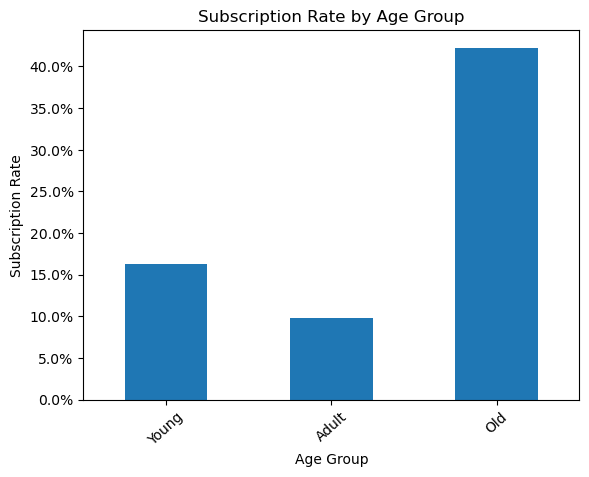

In [71]:
age_rate.plot(kind='bar')
plt.xlabel('Age Group')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Age Group')
plt.xticks(rotation=42)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()


**Insight:** Customers in the Old age group had the highest subscription rate (42.26%), while Adult customers had the lowest rate (9.85%).

### 5.2 Subscription Rate by Job

In [72]:
job_rate = (
    df.groupby('job', observed=True)['y']
      .apply(lambda x: (x == 'yes').mean())
)

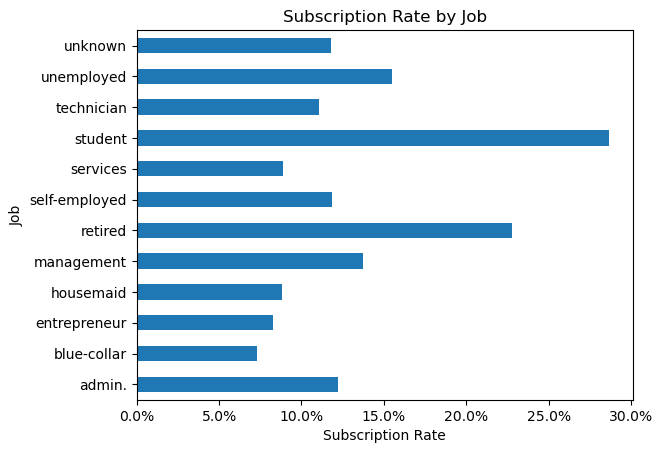

In [78]:
job_rate.plot(kind='barh')
plt.ylabel('Job')
plt.xlabel('Subscription Rate')
plt.title('Subscription Rate by Job')
plt.yticks(rotation=0)

plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.show()

**Insight:** Subscription rates vary across job categories. Student and retired customers show notably higher subscription rates than several other groups.

### 5.3 Subscription Rate by Call Duration

In [79]:
duration_rate = (
    df.groupby('duration_group', observed=True)['y']
      .apply(lambda x: (x == 'yes').mean())
)

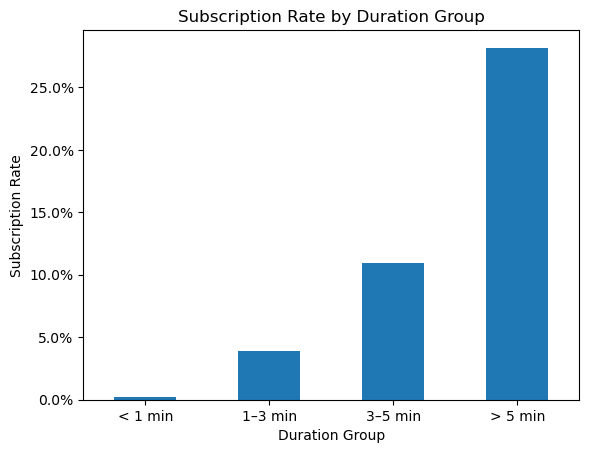

In [82]:
duration_rate.plot(kind='bar')
plt.xlabel('Duration Group')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Duration Group')
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

**Insight:** Subscription rates increase substantially as call duration increases, rising from 0.19% for calls under 1 minute to 28.17% for calls longer than 5 minutes.

### 5.4 Subscription Rate by Previous Campaign Outcome

In [83]:
poutcome_rate = (
    df.groupby('poutcome', observed=True)['y']
      .apply(lambda x: (x == 'yes').mean())
)

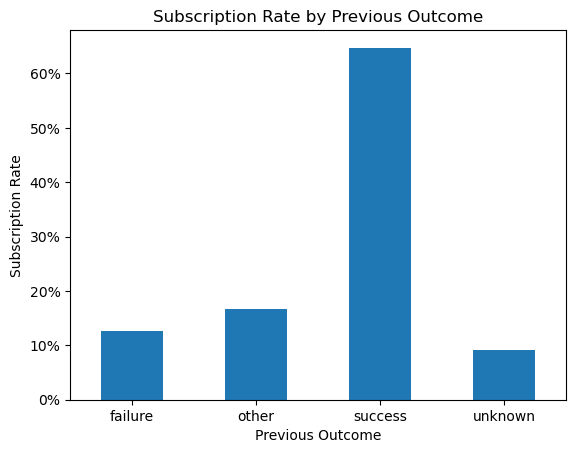

In [84]:
poutcome_rate.plot(kind='bar')
plt.xlabel('Previous Outcome')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Previous Outcome')
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

**Insight:** Customers with a successful previous campaign outcome had a substantially higher subscription rate (64.73%) than customers with other previous outcomes.

_____________________________________
### Note: Why `campaign` Was Excluded
`campaign` was considered during the analysis. Its mean was lower for subscribed customers (**2.14 vs 2.85**), but the median was **2 for both groups**.

Because this provides a relatively weak standalone insight, `campaign` is excluded from the final key findings to keep the analysis focused.
_________________________________________

## 6. Multivariate Analysis


### 6.1 Age Group + Job vs Subscription
**Question:** Does the relationship between age group and subscription change across different job categories?


In [ ]:
df['y'].groupby([df['age_group'], df['job']]).value_counts(normalize=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_4172\1518182893.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['y'].groupby([df['age_group'], df['job']]).value_counts(normalize=True)


age_group  job           y  
Young      admin.        no     0.851967
                         yes    0.148033
           blue-collar   no     0.888734
                         yes    0.111266
           entrepreneur  no     0.911111
                                  ...   
Old        technician    yes    0.333333
           unemployed    no     0.700000
                         yes    0.300000
           unknown       no     0.863636
                         yes    0.136364
Name: proportion, Length: 72, dtype: float64

In [ ]:
result = df['y'].groupby(
    [df['age_group'], df['job']]
).value_counts()

C:\Users\PC\AppData\Local\Temp\ipykernel_4172\4247111015.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df['y'].groupby(


In [ ]:
result.loc[:, :, 'yes']

age_group  job          
Young      admin.            143
           blue-collar       160
           entrepreneur       12
           housemaid           8
           management        234
           retired             0
           self-employed      52
           services           92
           student           235
           technician        169
           unemployed         36
           unknown             4
Adult      admin.            477
           blue-collar       540
           entrepreneur      104
           housemaid          80
           management       1020
           retired           141
           self-employed     118
           services          277
           student            34
           technician        661
           unemployed        163
           unknown            27
Old        admin.             11
           blue-collar         8
           entrepreneur        7
           housemaid          21
           management         47
           retired

**Interpretation:** Subscription patterns vary across age groups and job categories. However, some combinations contain very few customers, so individual percentages from tiny groups should not be treated as strong evidence.


### 6.2 Housing + Loan + Default vs Subscription
**Question:** Does the combination of housing loan, personal loan, and credit default relate to subscription?


In [ ]:
df['y'].groupby([df['housing'], df['loan'], df['default']]).value_counts(normalize=True)

housing  loan  default  y  
no       no    no       no     0.816384
                        yes    0.183616
               yes      no     0.929245
                        yes    0.070755
         yes   no       no     0.922111
                        yes    0.077889
               yes      no     0.952381
                        yes    0.047619
yes      no    no       no     0.919457
                        yes    0.080543
               yes      no     0.927152
                        yes    0.072848
         yes   no       no     0.939065
                        yes    0.060935
               yes      no     0.947368
                        yes    0.052632
Name: proportion, dtype: float64

In [ ]:
df['y'].groupby([df['housing'], df['loan'], df['default']]).value_counts()

housing  loan  default  y  
no       no    no       no     13872
                        yes     3120
               yes      no       197
                        yes       15
         yes   no       no      2498
                        yes      211
               yes      no       160
                        yes        8
yes      no    no       no     18813
                        yes     1648
               yes      no       280
                        yes       22
         yes   no       no      3976
                        yes      258
               yes      no       126
                        yes        7
Name: count, dtype: int64

**Insight:** The group with **no housing loan, no personal loan, and no credit default** has the highest subscription rate among the well-represented combinations (18.36%, with 16,992 customers). Small `default=yes` combinations should be interpreted cautiously.


__________________________________________________
## 7. Key Findings

### Strongest Findings
1. **`poutcome`** — previous campaign success is strongly associated with current subscription.
2. **`duration`** — longer calls show substantially higher subscription rates.
3. **`age_group`** — the Old group has a much higher subscription rate than the Adult group.
4. **`job`** — subscription rates differ considerably across occupations.
5. **`previous`** — prior campaign contact is more common among subscribers.

### Supporting Findings
- `housing` and `loan` show meaningful differences in subscription rates.
- Multivariate analysis adds context, while subgroup size must be considered.

### De-emphasized Variables
- `marital`: weak standalone pattern.
- `default`: limited standalone insight and some small groups.
- `contact`: removed because its signal was weaker than the retained variables.
- `campaign`: mean difference exists, but both groups have the same median.
- `pdays`: strongly tied to previous-contact history and does not add a clearly independent insight here.

> **EDA goal:** prioritize clear, reliable, and useful insights rather than giving every column equal weight.
